In [6]:
import numpy as np
import random
from tqdm import tqdm
from copy import deepcopy
import matplotlib.pyplot as plt

In [4]:
class Bee:
    def __init__(self, n_dim, param_limits=(-5, 5)):
        self.low = param_limits[0]
        self.high = param_limits[1]
        self.pos = np.random.uniform(
            low= self.low, high= self.high, size= (n_dim,)
        )
        self.fitness = -1e8
        self.counter = 0
    
    def explore(self, neighbour, task):
        phi = np.random.uniform(-1, 1, len(self.pos))
        new_pos = self.pos + phi * (self.pos - neighbour.pos)
        new_pos = np.clip(new_pos, self.low, self.high)

        new_fitness = task.score(new_pos)
        if new_fitness > self.fitness:
            self.pos = new_pos
            self.fitness = new_fitness
            self.counter = 0
        else:
            self.counter += 1

In [5]:
class Colony:
    def __init__(self, n_dim, n_population, param_limits):
        self.n_dim = n_dim
        self.bees = [Bee(n_dim, param_limits) for _ in range(n_population)]
        self.best_solution = np.zeros(n_dim)
        self.best_fitness = -1e8
        self.limit = 10
    
    def solve(self, task, num_iterations):
        for _ in tqdm(range(num_iterations)):
            # 'Employed bee' Phase
            for bee in self.bees:
                partner_idx = np.random.randint(len(self.bees))
                bee.explore(self.bees[partner_idx], task)

            # 'Onlooker bee' Phase
            fitnesses = np.array([bee.fitness for bee in self.bees])
            probs = fitnesses / fitnesses.sum()
            for _ in range(len(self.bees)):
                bee_idx = np.random.choice(range(len(self.bees)), p=probs)
                self.bees[bee_idx].explore(np.random.choice(self.bees), task)
            
            # 'Scout bee' Phase & Update best solution
            for bee in self.bees:
                if bee.counter > self.limit:
                    bee = Bee(self.n_dim, (bee.low, bee.high))
                if bee.fitness > self.best_fitness:
                    self.best_fitness = bee.fitness
                    self.best_solution = deepcopy(bee.pos)        
        return self.best_solution

z.shape:  (100, 100)


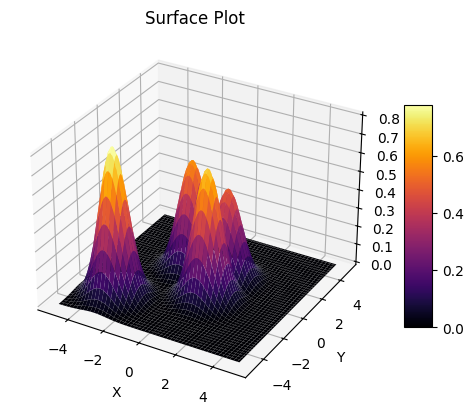

In [7]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)

def multipeak(x, y):
    peak1 = 0.5 * np.exp(-((x-1)**2 + (y-1)**2))
    peak2 = 0.6 * np.exp(-((x+1)**2 + (y-1)**2))
    peak3 = 0.7 * np.exp(-((x-1)**2 + (y+1)**2))
    peak4 = 0.8 * np.exp(-((x+3)**2 + (y+3)**2))
    return np.maximum.reduce([peak1, peak2, peak3, peak4])

z = multipeak(x, y)
print("z.shape: ", z.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(x, y, z, cmap='inferno')

ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.title('Surface Plot')
fig.colorbar(surface, shrink=0.6, aspect=8)
plt.show()

In [8]:
def full_blackbox(x1, y1, x2, y2, x3, y3, x4, y4):
    peak1 = 0.5 * np.exp(
        -((x1-1)**2 + (y1-1)**2 + (x2-1)**2 + (y2-1)**2 + (x3-1)**2 + (y3-1)**2 + (x4-1)**2 + (y4-1)**2)
    )
    peak2 = 0.6 * np.exp(
        -((x1+1)**2 + (y1-1)**2 + (x2+1)**2 + (y2-1)**2 + (x3+1)**2 + (y3-1)**2 + (x4+1)**2 + (y4-1)**2)
    )
    peak3 = 0.7 * np.exp(
        -((x1-1)**2 + (y1+1)**2 + (x2-1)**2 + (y2+1)**2 + (x3-1)**2 + (y3+1)**2 + (x4-1)**2 + (y4+1)**2)
    )
    peak4 = 0.8 * np.exp(
        -((x1+2)**2 + (y1+2)**2 + (x2+2)**2 + (y2+2)**2 + (x3+2)**2 + (y3+2)**2 + (x4+2)**2 + (y4+2)**2)
    )
    return np.maximum.reduce([peak1, peak2, peak3, peak4])

In [9]:
class Task:
    def __init__(self):
        pass
    
    def score(self, x_arr, with_noise=False):
        if with_noise:
            return full_blackbox(*x_arr) + 0.1*np.random.randn()
        else:
            return full_blackbox(*x_arr)

In [10]:
task = Task()
colony = Colony(n_dim=8, n_population=2000, param_limits=(-5, 5))
best_solution = colony.solve(task, 500)

print(best_solution)
print(task.score(best_solution))

  0%|          | 1/500 [00:03<33:00,  3.97s/it]


KeyboardInterrupt: 